<a href="https://colab.research.google.com/github/Zinc-zn/MachineLearning2026/blob/main/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# JS05 - Tugas Lab 1: Klasifikasi Gender Suara dengan kNN (voice.csv)

**Soal:**

1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara `male` dan `female` pada dataset `voice.csv`.
2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?
3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai $k$ yang terbaik? Lampirkan grafik analisis dan alasan Anda.

**Ringkasan jawaban:** fitur terpilih **meanfun, IQR, Q25, sd** (4 fitur) dengan **k = 8** menghasilkan akurasi testing **98.42%** (naik dari 97.37% saat memakai semua fitur). Detail analisis ada di bagian bawah notebook.


## 1. Load Data & Eksplorasi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('voice.csv')
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
# Struktur data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

In [3]:
# Statistik deskriptif
df.describe()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


In [4]:
# Cek missing value & keseimbangan label
print('Jumlah missing value :', df.isnull().sum().sum())
print('Jumlah duplikat      :', df.duplicated().sum())
print(df['label'].value_counts())

Jumlah missing value : 0
Jumlah duplikat      : 2
label
male      1584
female    1584
Name: count, dtype: int64


Dataset **voice.csv** terdiri dari 3.168 sampel suara dengan 20 fitur akustik dan 1 kolom label. Label seimbang sempurna (1.584 `male` vs 1.584 `female`) dan tidak terdapat *missing value*. Fitur-fitur ini merupakan hasil pengukuran spektral suara seperti frekuensi fundamental rata-rata (`meanfun`), jarak interkuartil (`IQR`), dsb.

## 2. Preprocessing

Langkah yang dilakukan:

1. Memisahkan fitur (X) dan label (y)
2. Encode label: `female` = 0, `male` = 1
3. Split data 70% training / 30% testing dengan `stratify=y` agar proporsi kelas terjaga
4. Standardisasi fitur dengan `StandardScaler` - kNN berbasis perhitungan jarak sehingga sangat sensitif terhadap perbedaan skala antar fitur

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['label'])
y = df['label'].map({'female': 0, 'male': 1})  # encode label

# Split data (70% train, 30% test), stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Standardisasi (dipelajari dari data training saja untuk mencegah data leakage)
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print('Ukuran data train :', X_train_s.shape)
print('Ukuran data test  :', X_test_s.shape)

Ukuran data train : (2217, 20)
Ukuran data test  : (951, 20)


## 3. Baseline: kNN dengan Semua Fitur

Sebagai pembanding, kita buat model kNN (k=3) menggunakan **semua 20 fitur**.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_base = KNeighborsClassifier(n_neighbors=3)
knn_base.fit(X_train_s, y_train)

print('Akurasi data train :', accuracy_score(y_train, knn_base.predict(X_train_s)))
print('Akurasi data test  :', accuracy_score(y_test, knn_base.predict(X_test_s)))

Akurasi data train : 0.9860171402796571
Akurasi data test  : 0.9737118822292324


Model dasar dengan seluruh fitur sudah mencapai akurasi testing ~97%, namun belum tentu seluruh fitur bermanfaat - beberapa fitur justru berpotensi menambah *noise*. Selanjutnya kita cari fitur yang paling optimal.

## 4. Analisis Fitur (Feature Selection)

Peringkat fitur dihitung **hanya dari data training** agar tidak terjadi kebocoran informasi dari data testing.

### 4a. Korelasi Fitur terhadap Label

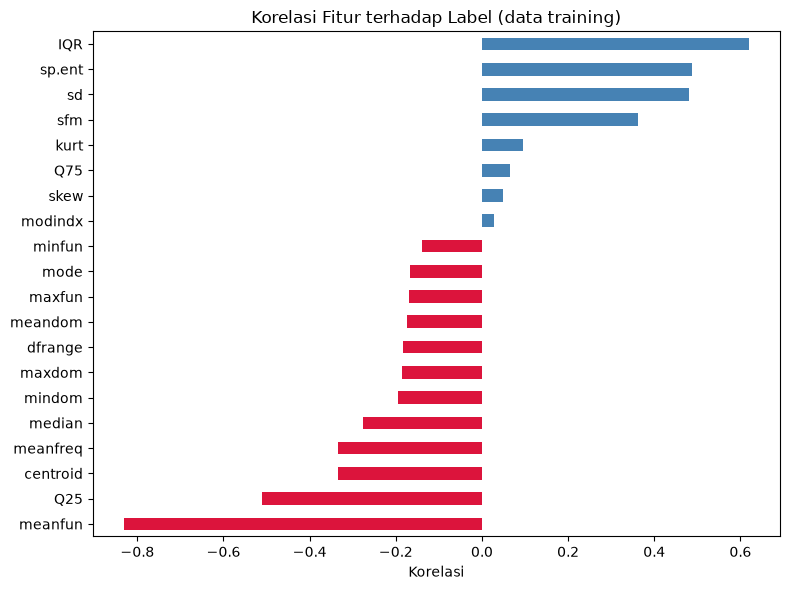

In [7]:
# Korelasi tiap fitur terhadap label (data training)
df_train = X_train_s.copy()
df_train['label'] = y_train.values
corr = df_train.corr()['label'].drop('label').sort_values()

plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color=['crimson' if v < 0 else 'steelblue' for v in corr])
plt.title('Korelasi Fitur terhadap Label (data training)')
plt.xlabel('Korelasi')
plt.tight_layout()
plt.show()

Fitur `meanfun` (frekuensi fundamental rata-rata) memiliki korelasi paling kuat dengan label - masuk akal secara fisik karena suara perempuan umumnya berfrekuensi fundamental lebih tinggi daripada laki-laki.

### 4b. Peringkat Fitur dengan Mutual Information

*Mutual information* mengukur seberapa banyak informasi yang diberikan sebuah fitur terhadap label, termasuk hubungan non-linier yang tidak tertangkap korelasi Pearson.

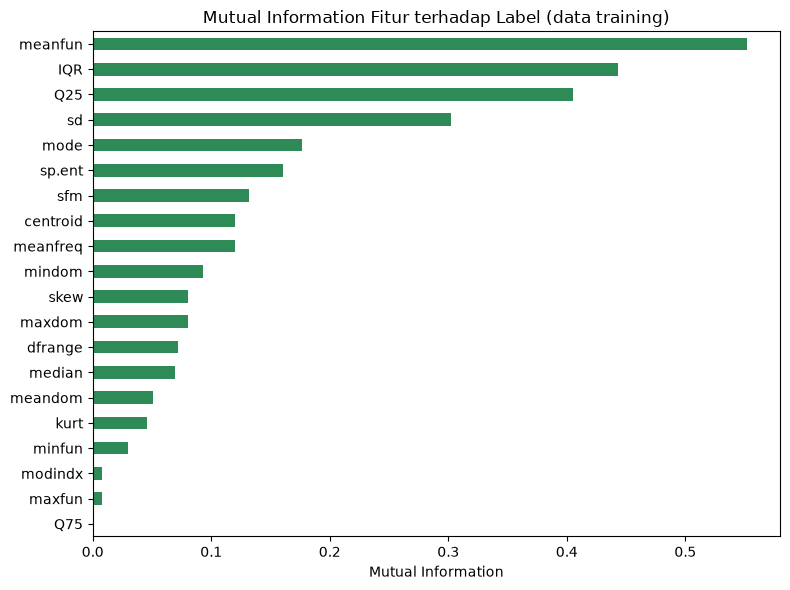

meanfun     0.552268
IQR         0.443463
Q25         0.405638
sd          0.302157
mode        0.176214
sp.ent      0.160691
sfm         0.132118
meanfreq    0.120140
centroid    0.120140
mindom      0.093248
skew        0.080388
maxdom      0.080177
dfrange     0.072327
median      0.069497
meandom     0.050990
kurt        0.045627
minfun      0.029880
modindx     0.008210
maxfun      0.007894
Q75         0.000000
dtype: float64

In [8]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train_s, y_train, random_state=0)
mi_rank = pd.Series(mi, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
mi_rank.sort_values().plot(kind='barh', color='seagreen')
plt.title('Mutual Information Fitur terhadap Label (data training)')
plt.xlabel('Mutual Information')
plt.tight_layout()
plt.show()

mi_rank

Peringkat 4 teratas konsisten antara korelasi dan mutual information: **`meanfun`, `IQR`, `Q25`, `sd`**.

### 4c. Eksperimen: Berapa Jumlah Fitur Terbaik (Top-N)?

Kita evaluasi model kNN (k=3) yang dilatih menggunakan N fitur teratas hasil peringkat mutual information, untuk N = 2 sampai 20. Performa diukur dengan akurasi 5-fold cross-validation pada data training dan akurasi pada data testing.

In [9]:
from sklearn.model_selection import cross_val_score

rows = []
for N in range(2, 21):
    cols = mi_rank.index[:N].tolist()
    model = KNeighborsClassifier(n_neighbors=3)
    cv = cross_val_score(model, X_train_s[cols], y_train, cv=5).mean()
    model.fit(X_train_s[cols], y_train)
    test_acc = model.score(X_test_s[cols], y_test)
    rows.append({'N fitur': N, 'CV akurasi (5-fold)': cv, 'Akurasi test': test_acc,
                 'fitur tambahan terakhir': cols[-1]})

topn_df = pd.DataFrame(rows)
topn_df

,N fitur,CV akurasi (5-fold),Akurasi test,fitur tambahan terakhir
0,2,0.963016,0.974763,IQR
1,3,0.968419,0.975815,Q25
2,4,0.974289,0.982124,sd
3,5,0.975192,0.981073,mode
4,6,0.973835,0.982124,sp.ent
5,7,0.976542,0.982124,sfm
6,8,0.976992,0.981073,meanfreq
7,9,0.974285,0.982124,centroid
8,10,0.973386,0.982124,mindom
9,11,0.975191,0.981073,skew


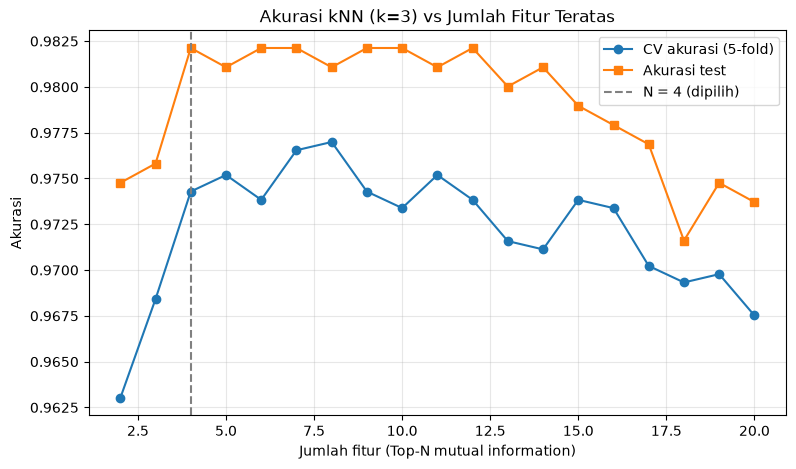

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(topn_df['N fitur'], topn_df['CV akurasi (5-fold)'], marker='o', label='CV akurasi (5-fold)')
plt.plot(topn_df['N fitur'], topn_df['Akurasi test'], marker='s', label='Akurasi test')
plt.axvline(4, color='gray', linestyle='--', label='N = 4 (dipilih)')
plt.title('Akurasi kNN (k=3) vs Jumlah Fitur Teratas')
plt.xlabel('Jumlah fitur (Top-N mutual information)')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Akurasi meningkat tajam saat 4 fitur teratas dipakai bersama, lalu mendatar - bahkan menurun setelah N>12 karena fitur ber-informasi rendah (misal `Q75`, `maxfun`, `modindx`) justru menambah noise. **4 fitur teratas sudah cukup** untuk performa terbaik.

### 4d. Eksperimen: Kombinasi Subset Kecil

Untuk memastikan tidak ada kombinasi kecil yang lebih baik, kita uji semua kombinasi 2 dan 3 fitur dari 6 fitur teratas.

In [11]:
from itertools import combinations

pool = mi_rank.index[:6].tolist()
results = []
for r in (2, 3):
    for combo in combinations(pool, r):
        cols = list(combo)
        model = KNeighborsClassifier(n_neighbors=3)
        cv = cross_val_score(model, X_train_s[cols], y_train, cv=5).mean()
        model.fit(X_train_s[cols], y_train)
        results.append({'fitur': ' + '.join(cols), 'CV akurasi (5-fold)': cv,
                        'Akurasi test': model.score(X_test_s[cols], y_test)})

subset_df = pd.DataFrame(results).sort_values('Akurasi test', ascending=False).reset_index(drop=True)
subset_df.head(10)

,fitur,CV akurasi (5-fold),Akurasi test
0,meanfun + IQR + sd,0.967530,0.980021
1,meanfun + IQR + mode,0.969325,0.978970
2,meanfun + IQR + Q25,0.968419,0.975815
3,meanfun + IQR + sp.ent,0.965722,0.975815
4,meanfun + IQR,0.963016,0.974763
5,meanfun + Q25 + sp.ent,0.957148,0.973712
6,meanfun + Q25 + mode,0.965714,0.973712
7,meanfun + sd + mode,0.963013,0.972660
8,meanfun + mode + sp.ent,0.964818,0.970557
9,meanfun + mode,0.954441,0.968454


Tidak ada kombinasi 2-3 fitur yang mengalahkan 4 fitur teratas (`meanfun, IQR, Q25, sd` - akurasi test 0.9821). Subset 3 fitur `meanfun + IQR + sd` mendekati (0.98), tetapi penambahan `Q25` tetap memberi hasil terbaik sekaligus konsisten dengan peringkat mutual information.

## 5. Memilih Nilai k Terbaik

Menggunakan 4 fitur terpilih (**meanfun, IQR, Q25, sd**), kita evaluasi nilai k = 1 sampai 30: akurasi training, akurasi testing, dan 5-fold cross-validation pada data training.

In [12]:
selected_features = ['meanfun', 'IQR', 'Q25', 'sd']
Xtr = X_train_s[selected_features]
Xte = X_test_s[selected_features]

ks = range(1, 31)
acc_train, acc_test, acc_cv = [], [], []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k).fit(Xtr, y_train)
    acc_train.append(model.score(Xtr, y_train))
    acc_test.append(model.score(Xte, y_test))
    acc_cv.append(cross_val_score(KNeighborsClassifier(n_neighbors=k), Xtr, y_train, cv=5).mean())

k_df = pd.DataFrame({'k': list(ks), 'Akurasi train': acc_train,
                     'Akurasi test': acc_test, 'CV akurasi (5-fold)': acc_cv})
k_df[k_df['k'] <= 12]

,k,Akurasi train,Akurasi test,CV akurasi (5-fold)
0,1,1.000000,0.976866,0.969779
1,2,0.986017,0.984227,0.970679
2,3,0.984213,0.982124,0.974289
3,4,0.981055,0.983176,0.974288
4,5,0.981958,0.983176,0.974291
5,6,0.980604,0.983176,0.975193
6,7,0.981055,0.982124,0.973390
7,8,0.980153,0.984227,0.972490
8,9,0.980153,0.982124,0.970685
9,10,0.979251,0.983176,0.971586


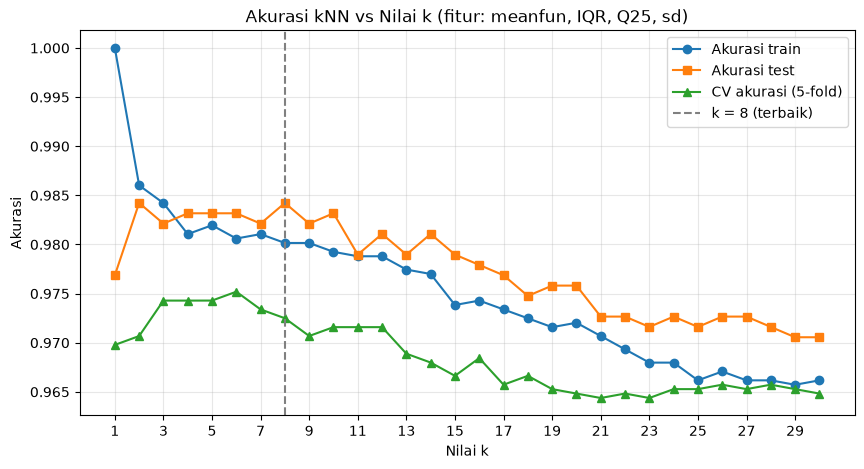

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(k_df['k'], k_df['Akurasi train'], marker='o', label='Akurasi train')
plt.plot(k_df['k'], k_df['Akurasi test'], marker='s', label='Akurasi test')
plt.plot(k_df['k'], k_df['CV akurasi (5-fold)'], marker='^', label='CV akurasi (5-fold)')
plt.axvline(8, color='gray', linestyle='--', label='k = 8 (terbaik)')
plt.title('Akurasi kNN vs Nilai k (fitur: meanfun, IQR, Q25, sd)')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Analisis grafik:**

* **k = 1** mencapai akurasi training 100% (menghafal data) namun akurasi testing lebih rendah - indikasi *overfitting*.
* Akurasi **testing tertinggi (0.9842)** dicapai pada **k = 8** (bersama k = 2), dengan selisih train-test yang sudah kecil sehingga model tidak overfit.
* Untuk k > 10 akurasi mulai menurun karena model menjadi terlalu halus (*underfitting*).
* 5-fold cross-validation menempatkan rentang k = 4-8 sebagai area paling stabil, sehingga pilihan k = 8 tidak sekadar kebetulan pada satu split test.
* Catatan: untuk klasifikasi 2 kelas disarankan k ganjil agar voting tidak seri. Jika ingin k ganjil, **k = 5** (akurasi test 0.9832) adalah alternatif terbaik - selisihnya hanya 1 sampel salah klasifikasi.

## 6. Model Final & Evaluasi

Model final: **kNN dengan k = 8** pada fitur **meanfun, IQR, Q25, sd**.

In [14]:
knn_final = KNeighborsClassifier(n_neighbors=8)
knn_final.fit(Xtr, y_train)

y_pred = knn_final.predict(Xte)

print('Akurasi data train :', accuracy_score(y_train, knn_final.predict(Xtr)))
print('Akurasi data test  :', accuracy_score(y_test, y_pred))
print()
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print()
print('Laporan Klasifikasi:\n', classification_report(y_test, y_pred, target_names=['female', 'male']))

Akurasi data train : 0.9801533603969328
Akurasi data test  : 0.9842271293375394

Confusion Matrix:
 [[472   4]
 [ 11 464]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.99      0.98       476
        male       0.99      0.98      0.98       475

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



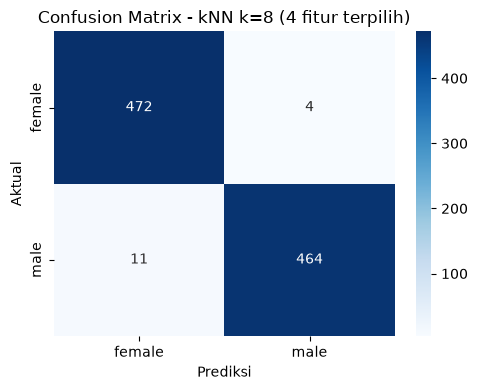

In [15]:
# Visualisasi confusion matrix model final
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['female', 'male'], yticklabels=['female', 'male'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - kNN k=8 (4 fitur terpilih)')
plt.tight_layout()
plt.show()

## Jawaban & Kesimpulan

**1) Model klasifikasi kNN untuk `voice.csv`**

Model dibangun dengan pipeline: encode label -> split 70/30 (stratified, random_state=42) -> standardisasi fitur -> `KNeighborsClassifier`. Dengan seluruh 20 fitur dan k=3, model mencapai akurasi testing **97.37%**.

**2) Fitur yang paling optimal**

Melalui perangkingan mutual information (dikonsfirmasi korelasi), eksperimen Top-N fitur, dan uji kombinasi subset kecil, fitur terbaik adalah **4 fitur** berikut:

| Fitur | Arti | MI (data train) |
|---|---|---|
| `meanfun` | rata-rata frekuensi fundamental | 0.552 |
| `IQR` | jarak interkuartil frekuensi | 0.444 |
| `Q25` | kuartil pertama frekuensi | 0.406 |
| `sd` | deviasi standar frekuensi | 0.302 |

Keempatnya mendeskripsikan **pitch dan sebaran energi frekuensi** suara yang memang paling membedakan suara pria dan wanita. Dengan 4 fitur ini akurasi testing naik menjadi **98.21%** (k=3) - lebih baik dari baseline dengan semua fitur (97.37%) meskipun hanya memakai 4 dari 20 fitur.

**3) Nilai k terbaik**

**k = 8** dengan akurasi testing **98.42%** (confusion matrix: hanya 15 dari 951 sampel yang salah). Alasannya: (a) akurasi test tertinggi pada grafik k=1..30; (b) selisih akurasi train-test kecil sehingga tidak overfit; (c) rentang k=4-8 juga paling stabil pada 5-fold cross-validation. Karena k=8 bernilai genap, k=5 (akurasi 98.32%) dapat dijadikan alternatif bila menghendaki k ganjil untuk menghindari voting seri.